In [1]:
%load_ext autoreload
%autoreload 2
%load_ext line_profiler
import moabb
from moabb.datasets import *
from moabb.paradigms import P300
from hoda.hoda import HODA
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mne.viz import plot_topomap
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
from sklearn.manifold import TSNE
from mne import combine_evoked

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
fmax=16
sfreq=64
paradigm = P300(resample=sfreq, tmin=0, tmax=0.8, fmin=0.5, fmax=fmax)
#dataset = EPFLP300()
#subject, session, run = 1, "session_1", "run_1"
dataset = BNCI2014009()
subject, session, run = 1, "session_0", "run_0"

In [3]:
dataset.download(subject_list=[subject])
data = dataset.get_data(subjects=[subject])
raw = data[subject][session][run]
raw.info
epochs, labels, _ = paradigm.process_raw(raw, dataset, return_epochs=True)
epochs

Creating RawArray with float64 data, n_channels=18, n_times=50184
    Range : 0 ... 50183 =      0.000 ...   196.027 secs
Ready.
Creating RawArray with float64 data, n_channels=18, n_times=50184
    Range : 0 ... 50183 =      0.000 ...   196.027 secs
Ready.
Creating RawArray with float64 data, n_channels=18, n_times=50184
    Range : 0 ... 50183 =      0.000 ...   196.027 secs
Ready.
Not setting metadata
576 matching events found
No baseline correction applied


Number of events,576
Events,NonTarget: 480Target: 96
Time range,0.000 – 0.797 sec
Baseline,off


No projector specified for this dataset. Please consider the method self.add_proj.


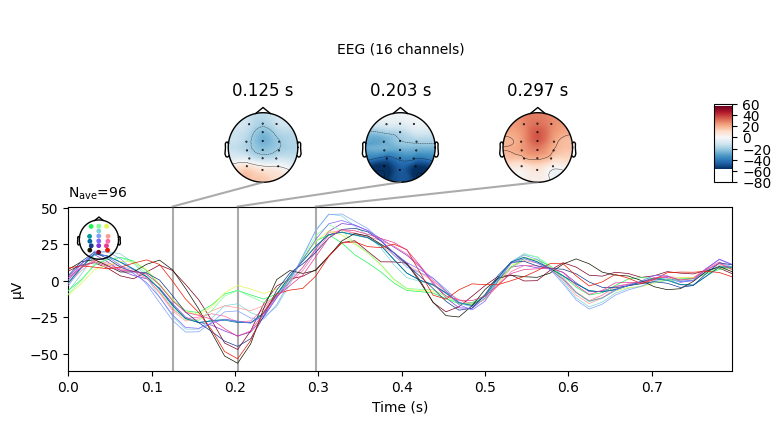

No projector specified for this dataset. Please consider the method self.add_proj.


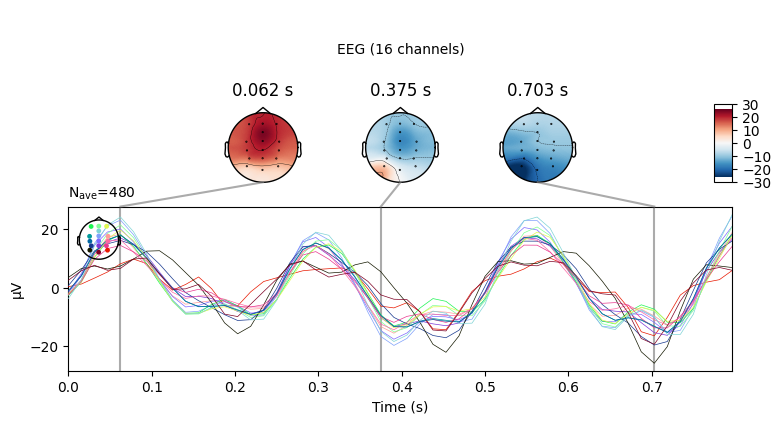

No projector specified for this dataset. Please consider the method self.add_proj.


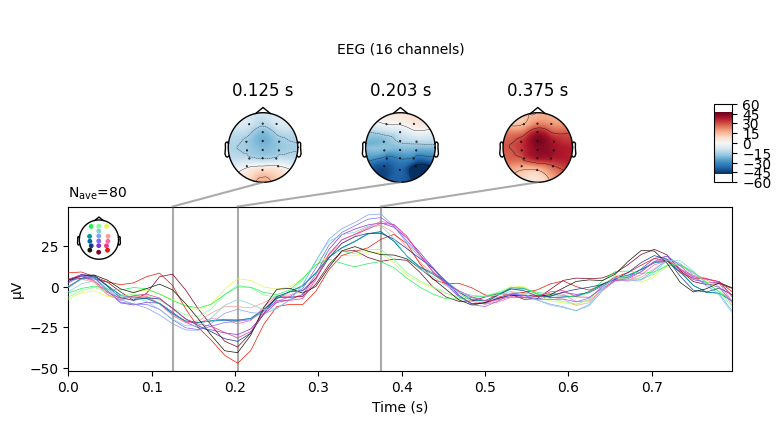

In [4]:
from mne import combine_evoked

target = epochs['Target'].average()
non_target = epochs['NonTarget'].average()
contrast = combine_evoked([target, non_target], weights=[1,-1])
#contrast.apply_baseline((-0.2,0))
target.plot_joint()
non_target.plot_joint()
_= contrast.plot_joint()

In [5]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl

tl.set_backend('numpy')

X = epochs.get_data().astype(np.float64)
y = labels

X.shape


(576, 16, 52)

In [38]:
import cupy
from hoda.tenalg import force_toeplitz
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from mne.decoding import Scaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import FunctionTransformer


hoda = HODA(
            rank=None,
            max_iter=256,
            tol=1e-3,
            init ='mlsvd',
            verbose=True,
            shrinkage=('lw','lw'),
            toeplitz=(1,),
            solver='lfl',
            keep_train_info=True,
            taper=False,
            #solver_params=dict(psi=0.1),
        )
hoda.fit(X,y)

Initializing factors...
Fitting discriminative tucker model of rank [2, 2] ...


  0%|          | 0/256 [00:00<?, ?it/s]

HODA(keep_train_info=True, max_iter=256, shrinkage=('lw', 'lw'), solver='lfl',
     toeplitz=(1,), tol=0.001, verbose=True)

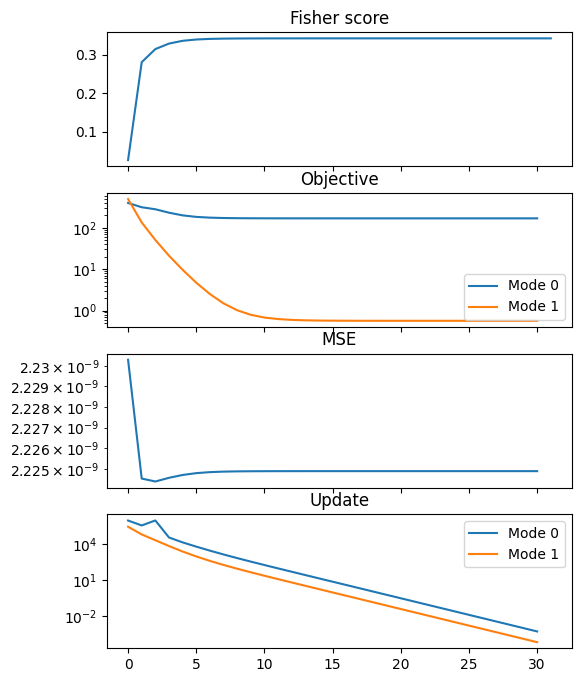

In [54]:
fig, axs = plt.subplots(4,1, sharex=True, figsize=(6,8))

axs[0].set_title('Fisher score')
axs[0].plot(hoda.train_info_["f_score"])

axs[1].set_title('Objective')
axs[1].semilogy(np.asarray(hoda.train_info_["mode_objective"]).T, label=['Mode 0', 'Mode 1'])
axs[1].legend()

axs[2].set_title('MSE')
axs[2].semilogy(hoda.train_info_["mse"])

axs[3].set_title('Update')
axs[3].semilogy(np.asarray(hoda.train_info_["mode_update"]).T, label=['Mode 0', 'Mode 1'])
axs[3].legend()

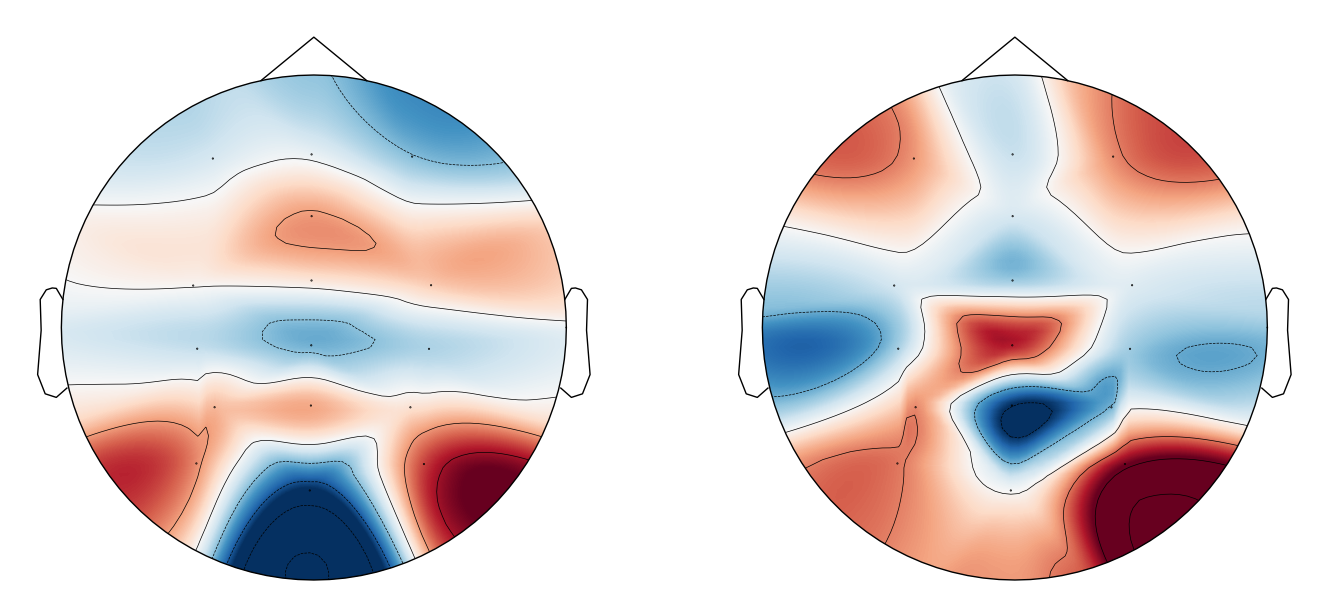

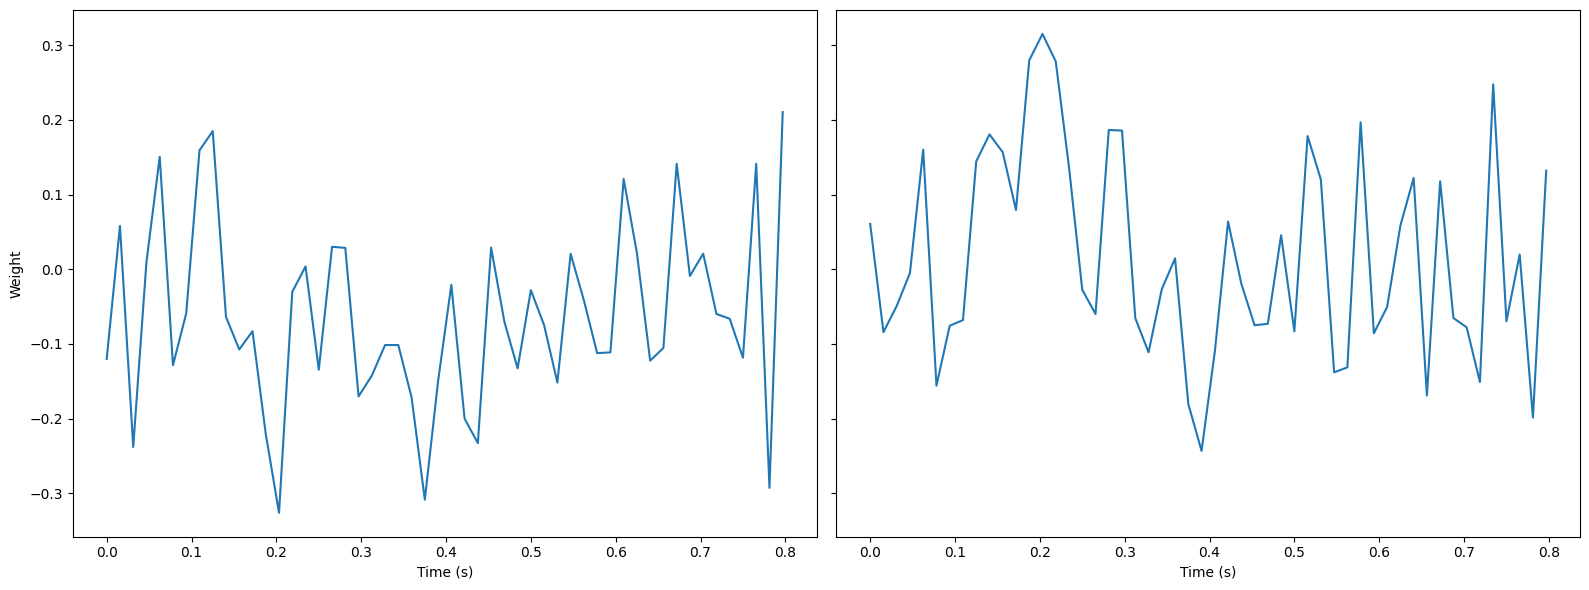

In [40]:
fig, axs = plt.subplots(1,max(hoda.rank_[0],2), figsize=(16,6), layout='tight')
for i in range(hoda.rank_[0]):
    w = cupy.asnumpy(hoda.scalings_[0][:,i])
    plot_topomap(w, epochs.info, axes=axs[i], show=False)

fig, axs = plt.subplots(1,max(hoda.rank_[1],2), figsize=(16,6), layout='tight', sharex=True, sharey=True)
for i in range(hoda.rank_[1]):
    w = cupy.asnumpy(hoda.scalings_[1][:,i])
    axs[i].plot(epochs.times, w)
    axs[i].set_xlabel('Time (s)')
    axs[i].sharey(axs[0])
axs[0].set_ylabel('Weight');


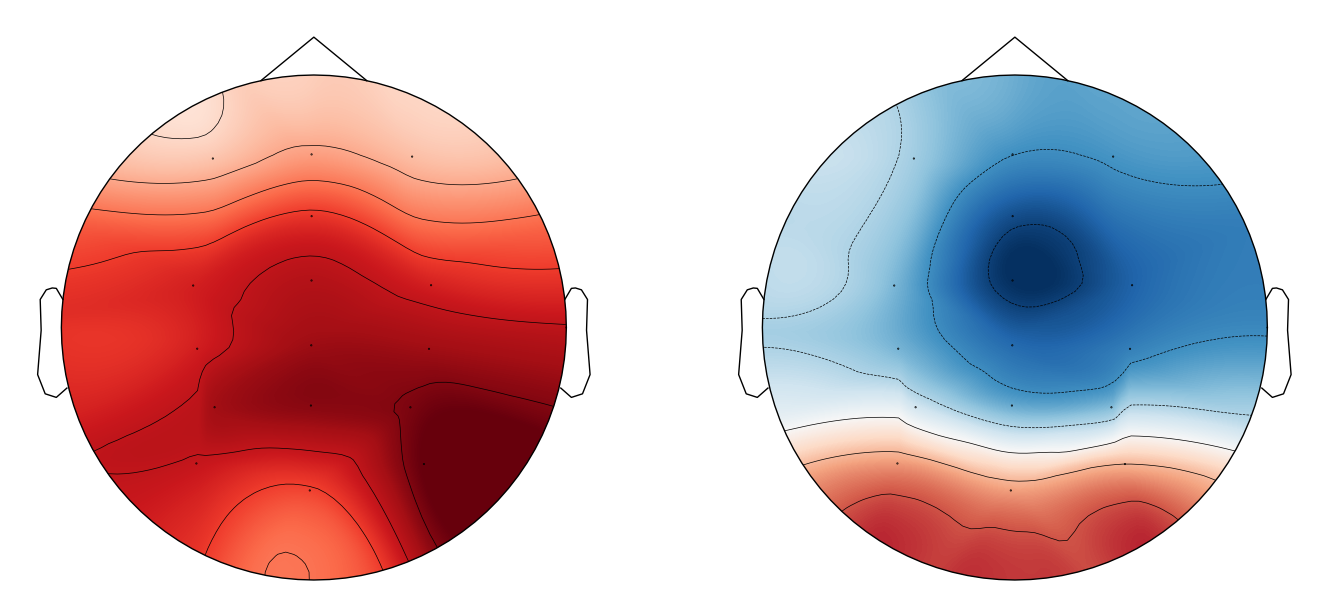

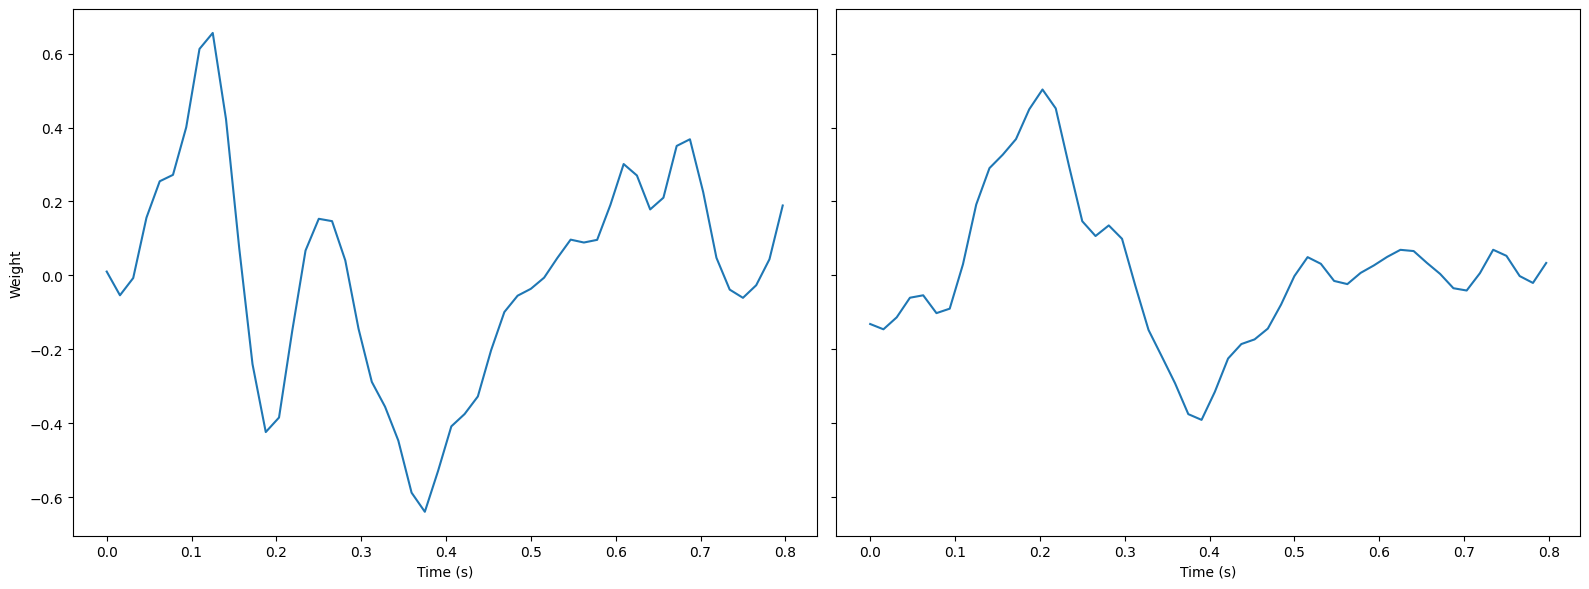

In [49]:

fig, axs = plt.subplots(1,max(hoda.rank_[0],2), figsize=(16,6), layout='tight')
A = hoda.scatter_w_[0] @ hoda.scalings_[0] @ hoda.cov_l_inv_[0]
for i in range(hoda.rank_[0]):
    a = cupy.asnumpy(A[:,i])
    plot_topomap(a, epochs.info, axes=axs[i], show=False)

    
fig, axs = plt.subplots(
    1,max(hoda.rank_[1],2),
    figsize=(16,6),
    layout='tight', 
    sharex=True,
    sharey=True
)

A = hoda.scatter_w_[1] @ hoda.scalings_[1] @ hoda.cov_l_inv_[1]

for i in range(hoda.rank_[1]):
    a = cupy.asnumpy(A[:,i])
    axs[i].plot(epochs.times, a)
    axs[i].set_xlabel('Time (s)')
    axs[i].sharey(axs[0])
axs[0].set_ylabel('Weight');

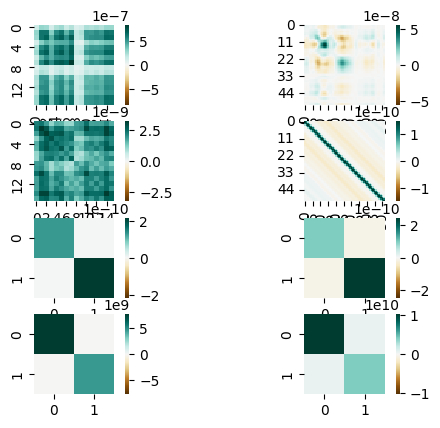

In [50]:
_, axs = plt.subplots(4,2)
for k in range(2):
    
    scatter_b = cupy.asnumpy(hoda.scatter_b_[k])
    vmax = np.max(np.abs(scatter_b))
    axs[0,k].set_aspect('equal')
    sns.heatmap(scatter_b, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[0,k])    
    
    scatter_w = cupy.asnumpy(hoda.scatter_w_[k])
    vmax = np.max(np.abs(scatter_w))
    sns.heatmap(scatter_w, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[1,k])    
    axs[1,k].set_aspect('equal')

    cov_l= cupy.asnumpy(hoda.cov_l_[k])
    vmax = np.max(np.abs(cov_l))
    sns.heatmap(cov_l, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[2,k])    
    axs[2,k].set_aspect('equal')
    
    cov_l_inv= cupy.asnumpy(hoda.cov_l_inv_[k])
    vmax = np.max(np.abs(cov_l_inv))
    sns.heatmap(cov_l_inv, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[3,k])    
    axs[3,k].set_aspect('equal')

In [51]:
Xt = hoda.transform(X)
Xt

array([[[ 1.27896482e-05, -2.41089510e-05],
        [-2.83827276e-06,  5.77521243e-06]],

       [[ 6.13192199e-06,  9.43547325e-06],
        [ 1.43371403e-05, -2.94972125e-06]],

       [[-5.85631265e-06, -3.80826995e-05],
        [-5.48113581e-06, -3.80060224e-05]],

       ...,

       [[-4.92445937e-06, -4.45498968e-05],
        [ 2.43745623e-05,  1.70853086e-05]],

       [[-3.57646358e-06,  2.83169295e-05],
        [-5.33248508e-06, -7.07652089e-06]],

       [[ 9.88936283e-06, -1.51054213e-05],
        [ 1.93995025e-06,  1.65928276e-05]]])

<AxesSubplot: >

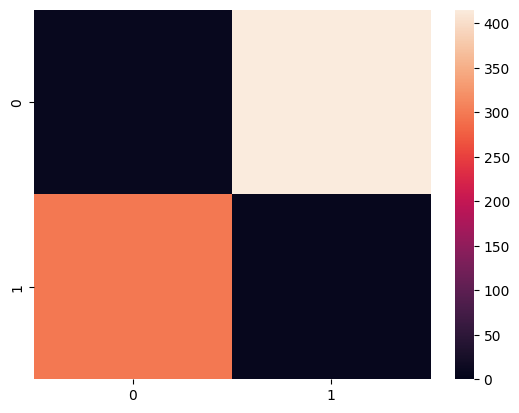

In [52]:
import scipy.stats
import seaborn as sns

samples = []
for c in hoda.classes_:
    samples.append(cupy.asnumpy(Xt)[y==c])
F,p = scipy.stats.f_oneway(*samples, axis=0)
sns.heatmap(F, mask=p>0.05,vmin=0)


No projector specified for this dataset. Please consider the method self.add_proj.


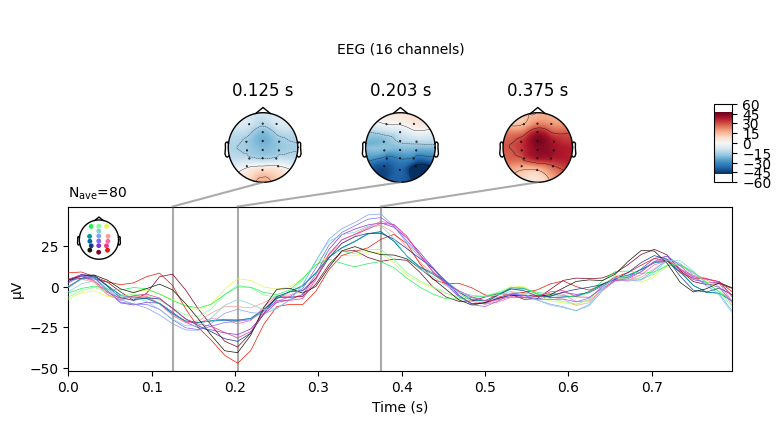

AttributeError: 'HODA' object has no attribute 'scalings'

In [59]:
target = epochs['Target'].average()
non_target = epochs['NonTarget'].average()
contrast = combine_evoked([target, non_target], weights=[1,-1])
_= contrast.plot_joint()

epochs_rec = epochs.copy()
epochs_rec._data = hoda.inv_transform(Xt)

target = epochs_rec['Target'].average()
non_target = epochs_rec['NonTarget'].average()
contrast = combine_evoked([target, non_target], weights=[1,-1])
_= contrast.plot_joint()

epochs_defl = epochs.copy()
epochs_defl._data -= epochs_rec.get_data()

target = epochs_defl['Target'].average()
non_target = epochs_defl['NonTarget'].average()
contrast = combine_evoked([target, non_target], weights=[1,-1])
_= contrast.plot_joint()